<a href="https://colab.research.google.com/github/ayushmanpathak9034/MLE-Case-Study-2/blob/main/MLE_CS_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Ayushman Pathak 202501100300080 AI B</h1>
<h1>Case Study 2 : Credit Card Fraud Detection — Apply XGBoost on a heavily imbalanced transactions dataset (e.g. Kaggle IEEE-CIS). Use SMOTE for oversampling, tune decision thresholds, and interpret results with feature importance scores.</h1>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb

In [2]:
df = pd.read_csv('/content/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [3]:
scaler = StandardScaler()
df['std_amount'] = scaler.fit_transform(df[['Amount']])
df['std_time'] = scaler.fit_transform(df[['Time']])

In [4]:
df_filter = df.drop(columns=['Time', 'Amount'])

In [5]:
df_filter.sample(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,std_amount,std_time
32979,-1.116624,-0.113825,1.164706,1.068759,0.542018,-0.345515,1.195639,-0.358953,-0.431803,0.013537,...,0.724697,0.636660,0.082587,-0.162984,-0.313841,0.039563,-0.157153,0.0,0.164364,0.913784
35269,1.272860,-0.051095,0.306201,0.027162,-0.518907,-0.792303,-0.109634,-0.108523,0.426159,-0.172863,...,-1.133471,0.133826,-0.132563,0.064469,0.506779,-0.068914,0.010905,0.0,-0.279011,0.993143
21516,1.311645,-0.163834,0.115787,-0.443020,-0.217566,-0.042411,-0.366623,0.086734,0.299515,-0.028326,...,-0.524345,-0.057666,-0.790176,0.222445,0.960621,-0.080778,-0.012810,0.0,-0.340060,0.492277
24139,-0.362720,-0.836856,2.235070,-2.197650,-1.279450,0.408862,-1.132459,0.306352,-2.071355,1.062887,...,0.825491,-0.161395,-0.507521,-0.227231,-0.054826,0.158106,0.123468,0.0,-0.181127,0.600545
1346,-0.202717,-0.409711,1.008929,0.130943,-1.499126,1.021929,-1.522395,-2.443950,1.196464,-1.557942,...,1.180265,-0.308460,0.105945,0.861746,-0.175620,0.185887,0.284696,0.0,0.474855,-1.936650


In [6]:
# Remove rows having missing Class values
df = df.dropna(subset=['Class'])

# Convert target to integer
df['Class'] = df['Class'].astype(int)

X = df.drop(columns=['Class'])
y = df['Class']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
print(f"Original Training Set Size: {X_train.shape[0]}")
print(f"Original Training Fraud Count: {y_train.sum()}")

Original Training Set Size: 31760
Original Training Fraud Count: 83


In [9]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [10]:
print(f"Balanced Training Set Size (after SMOTE): {X_train_resampled.shape[0]}")
print(f"Balanced Training Fraud Count: {y_train_resampled.sum()}")

Balanced Training Set Size (after SMOTE): 63354
Balanced Training Fraud Count: 31677


In [11]:
model = xgb.XGBClassifier(n_estimators=100,max_depth=6,learning_rate=0.1,objective='binary:logistic',eval_metric='logloss', random_state=42,n_jobs=-1)

In [12]:
print("Training XGBoost model...")
model.fit(X_train_resampled, y_train_resampled)

Training XGBoost model...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [13]:
y_probs = model.predict_proba(X_test)[:, 1]

In [14]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1-Score: {f1:.4f} | "
        f"(TP: {tp}, FP: {fp}, FN: {fn})"
    )

Threshold: 0.1 | Precision: 0.7692 | Recall: 0.9524 | F1-Score: 0.8511 | (TP: 20, FP: 6, FN: 1)
Threshold: 0.3 | Precision: 0.8333 | Recall: 0.9524 | F1-Score: 0.8889 | (TP: 20, FP: 4, FN: 1)
Threshold: 0.5 | Precision: 0.8696 | Recall: 0.9524 | F1-Score: 0.9091 | (TP: 20, FP: 3, FN: 1)
Threshold: 0.7 | Precision: 0.8696 | Recall: 0.9524 | F1-Score: 0.9091 | (TP: 20, FP: 3, FN: 1)
Threshold: 0.9 | Precision: 0.9524 | Recall: 0.9524 | F1-Score: 0.9524 | (TP: 20, FP: 1, FN: 1)


<Figure size 1000x600 with 0 Axes>

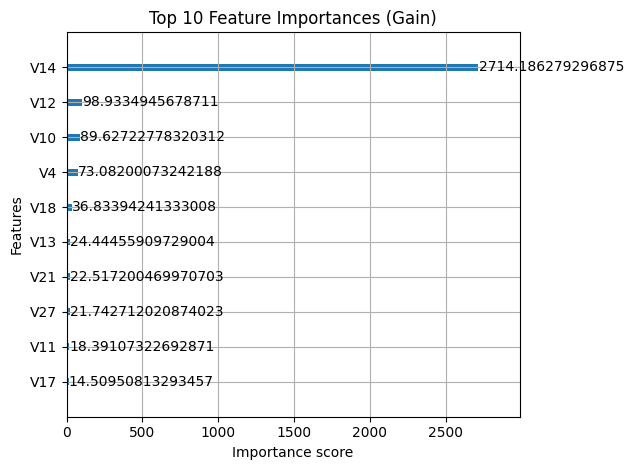

In [15]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, max_num_features=10, importance_type='gain', title='Top 10 Feature Importances (Gain)')
plt.tight_layout()
plt.show()